# Detect discontinuities in storm tracks

This notebook scans the connected storm-track DataFrames for each simulation (`ERA5`, `UBB`, `UBD`, `UBE`, `UBF`, `UBG`, `UBH`, `UBI`) and flags lines that look physically inconsistent within a single storm (same storm ID).

Types of discontinuity checked (all between two consecutive points of the **same storm**, ordered by the `point` column):

1. **Time gap** different from +1 h (includes going backwards, duplicates, and gaps).
2. **Latitude jump** > 1°.
3. **Longitude jump** > 1° (handled modulo 360 so the -180↔180 seam is ignored).
4. **Pressure jump** > 2 hPa.
5. **Longitude convention mixing**: a storm that contains both lon values < -10 and lon values > 190 (clear sign that the Fortran algorithm swapped between the -180:180 and 0:360 grids for the same track).

The goal here is purely **diagnostic**: produce a per-simulation count, identify the worst storms, and persist a CSV of every suspect line so a correction step can be built on top of it later.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from ETC_tools import open_files

In [2]:
SIMS = ['ERA5', 'UBB', 'UBD', 'UBE', 'UBF', 'UBG', 'UBH', 'UBI']

# Thresholds
LAT_THRESHOLD = 5.0      # degrees
LON_THRESHOLD = 5.0      # degrees (after modulo-360 wrapping)
PRES_THRESHOLD = 8.0     # hPa
EXPECTED_DT = pd.Timedelta(hours=1)

OUTPUT_DIR = '/home/vdemeyer/projects/rrg-gachon/vdemeyer/TRACKING/KATJA/OUTPUTS/DISCONTINUITIES'
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [3]:
def wrapped_lon_diff(lon_a, lon_b):
    """Absolute longitude difference accounting for wrap-around.

    Works whether the inputs are in -180:180 or 0:360. For a same-storm
    convention flip (e.g. -112.03 -> 247.97) this returns ~0, which is the
    correct physical answer. Convention mixing is detected separately below.
    """
    d = np.abs(lon_a - lon_b) % 360.0
    return np.minimum(d, 360.0 - d)


def detect_storm_discontinuities(df, sim):
    """Return a DataFrame of suspect rows (one row per flagged transition).

    df is assumed to be the output of ETC_tools.open_files, i.e. columns
    [storm, point, i, j, date, lat, lon, pressure] with `date` as datetime.
    """
    # Sort inside each storm by point number — this is the algorithm's own
    # trajectory order, which is what we want to audit. Sorting by date
    # would hide the bug (the date column itself can be wrong).
    df = df.sort_values(['storm', 'point']).reset_index(drop=True)

    g = df.groupby('storm', sort=False)

    # Next-row values within each storm (NaN at the last point of each storm)
    lat_next = g['lat'].shift(-1)
    lon_next = g['lon'].shift(-1)
    date_next = g['date'].shift(-1)
    pres_next = g['pressure'].shift(-1)
    storm_next = g['storm'].shift(-1)

    same_storm = df['storm'] == storm_next

    dlat = (lat_next - df['lat']).abs()
    dlon = wrapped_lon_diff(lon_next.values, df['lon'].values)
    dt = (date_next - df['date'])
    dp = (pres_next - df['pressure']).abs()

    flag_lat = same_storm & (dlat > LAT_THRESHOLD)
    flag_lon = same_storm & (pd.Series(dlon, index=df.index) > LON_THRESHOLD)
    flag_dt = same_storm & (dt != EXPECTED_DT)
    flag_pres = same_storm & (dp > PRES_THRESHOLD)

    any_flag = flag_lat | flag_lon | flag_dt | flag_pres

    suspects = df.loc[any_flag, ['storm', 'point', 'date', 'lat', 'lon', 'pressure']].copy()
    suspects['next_date'] = date_next[any_flag].values
    suspects['next_lat'] = lat_next[any_flag].values
    suspects['next_lon'] = lon_next[any_flag].values
    suspects['next_pressure'] = pres_next[any_flag].values
    suspects['dlat'] = dlat[any_flag].values
    suspects['dlon_wrapped'] = pd.Series(dlon, index=df.index)[any_flag].values
    suspects['dt'] = dt[any_flag].values
    suspects['dpressure'] = (pres_next - df['pressure'])[any_flag].values
    suspects['flag_lat'] = flag_lat[any_flag].values
    suspects['flag_lon'] = flag_lon[any_flag].values
    suspects['flag_dt'] = flag_dt[any_flag].values
    suspects['flag_pres'] = flag_pres[any_flag].values
    suspects['sim'] = sim

    # Convention-mixing check at the storm level
    has_neg = g['lon'].min() < -10.0
    has_high = g['lon'].max() > 190.0
    mixed_storms = has_neg.index[(has_neg & has_high).values].tolist()

    return suspects, mixed_storms

In [4]:
all_suspects = []
summary_rows = []
mixed_storms_per_sim = {}

for sim in SIMS:
    print(f'\n=== {sim} ===')
    df, _ = open_files(sim, period_filtering=False)

    suspects, mixed_storms = detect_storm_discontinuities(df, sim)
    mixed_storms_per_sim[sim] = mixed_storms

    n_total_rows = len(df)
    n_total_storms = df['storm'].nunique()
    n_flagged_transitions = len(suspects)
    n_flagged_storms = suspects['storm'].nunique()

    summary_rows.append({
        'sim': sim,
        'n_rows': n_total_rows,
        'n_storms': n_total_storms,
        'n_flagged_transitions': n_flagged_transitions,
        'n_flagged_storms': n_flagged_storms,
        'pct_storms_flagged': 100 * n_flagged_storms / max(n_total_storms, 1),
        'n_lon_convention_mixed_storms': len(mixed_storms),
        'n_time_flags': int(suspects['flag_dt'].sum()),
        'n_lat_flags': int(suspects['flag_lat'].sum()),
        'n_lon_flags': int(suspects['flag_lon'].sum()),
        'n_pres_flags': int(suspects['flag_pres'].sum()),
    })

    suspects.to_csv(f'{OUTPUT_DIR}/discontinuities_{sim}.csv', index=False)
    all_suspects.append(suspects)
    print(f'  storms={n_total_storms}, flagged storms={n_flagged_storms} '
          f'({100*n_flagged_storms/max(n_total_storms,1):.2f}%), '
          f'flagged transitions={n_flagged_transitions}, '
          f'lon-convention-mixed storms={len(mixed_storms)}')

summary = pd.DataFrame(summary_rows)
summary.to_csv(f'{OUTPUT_DIR}/summary.csv', index=False)
summary


=== ERA5 ===
Loading data from: /home/vdemeyer/projects/rrg-gachon/vdemeyer/TRACKING/KATJA/OUTPUTS/EETC/EETC_cum_ERA5_Quebec_1000hPa_1979-2023_compound_8hrs_quantile_SSI_diff.pkl with False period filtering
  storms=13806, flagged storms=695 (5.03%), flagged transitions=814, lon-convention-mixed storms=0

=== UBB ===
Loading data from: /home/vdemeyer/projects/rrg-gachon/vdemeyer/TRACKING/KATJA/OUTPUTS/EETC/EETC_cum_UBB_Quebec_1000hPa_1979-2023_compound_8hrs_quantile_SSI_diff.pkl with False period filtering
  storms=13230, flagged storms=421 (3.18%), flagged transitions=454, lon-convention-mixed storms=0

=== UBD ===
Loading data from: /home/vdemeyer/projects/rrg-gachon/vdemeyer/TRACKING/KATJA/OUTPUTS/EETC/EETC_cum_UBD_Quebec_1000hPa_1979-2014_compound_8hrs_quantile_SSI_diff.pkl with False period filtering
  storms=10722, flagged storms=330 (3.08%), flagged transitions=378, lon-convention-mixed storms=4

=== UBE ===
Loading data from: /home/vdemeyer/projects/rrg-gachon/vdemeyer/TRACKIN

,sim,n_rows,n_storms,n_flagged_transitions,n_flagged_storms,pct_storms_flagged,n_lon_convention_mixed_storms,n_time_flags,n_lat_flags,n_lon_flags,n_pres_flags
0,ERA5,834090,13806,814,695,5.034043,0,0,0,811,3
1,UBB,854638,13230,454,421,3.182162,0,0,0,454,0
2,UBD,726771,10722,378,330,3.077784,4,11,9,370,5
3,UBE,701657,10385,274,250,2.407318,0,0,0,274,0
4,UBF,845756,11672,309,281,2.407471,6,11,9,299,7
5,UBG,2446069,35603,1292,1166,3.275005,5,14,14,1280,6
6,UBH,2377645,35152,1132,1032,2.935822,0,0,0,1132,0
7,UBI,2799349,38053,1046,932,2.449216,17,33,30,1020,19


## Top storms by number of flagged transitions

Useful to eyeball the worst offenders and decide if they are isolated single-point glitches or full track corruption.

In [5]:
all_suspects_df = pd.concat(all_suspects, ignore_index=True)

top_per_sim = (all_suspects_df
               .groupby(['sim', 'storm']).size()
               .rename('n_flags')
               .reset_index()
               .sort_values(['sim', 'n_flags'], ascending=[True, False])
               .groupby('sim').head(10))
top_per_sim

,sim,storm,n_flags
12,ERA5,261,4
26,ERA5,627,4
404,ERA5,7435,4
19,ERA5,473,3
25,ERA5,615,3
...,...,...,...
4216,UBI,1550,3
4365,UBI,7975,3
4571,UBI,16718,3
4643,UBI,20505,3


In [6]:
# Quick sanity: show the UBI 2067 storm 255 transition that motivated this notebook
ubi_suspects = all_suspects_df[(all_suspects_df['sim'] == 'UBI') & (all_suspects_df['storm'] == 28426)]
ubi_suspects.head(20)

,storm,point,date,lat,lon,pressure,next_date,next_lat,next_lon,next_pressure,dlat,dlon_wrapped,dt,dpressure,flag_lat,flag_lon,flag_dt,flag_pres,sim
5398,28426,500,2067-09-04 13:00:00,49.67,-47.89,975.477,2067-09-05 01:00:00,20.99,-111.88,1004.460,28.68,63.99,0 days 12:00:00,28.983,True,True,True,True,UBI
5399,28426,502,2067-09-05 02:00:00,21.18,-112.03,1004.940,2067-09-04 21:00:00,21.18,247.97,1004.500,0.00,0.00,-1 days +19:00:00,-0.440,False,False,True,False,UBI
5400,28426,503,2067-09-04 21:00:00,21.18,247.97,1004.500,2067-09-04 17:00:00,10.26,288.20,973.441,10.92,40.23,-1 days +20:00:00,-31.059,True,True,True,True,UBI
5401,28426,504,2067-09-04 17:00:00,10.26,288.20,973.441,2067-09-04 18:00:00,50.56,-46.29,973.124,40.30,25.51,0 days 01:00:00,-0.317,True,True,False,False,UBI


## Distribution of flag types per simulation

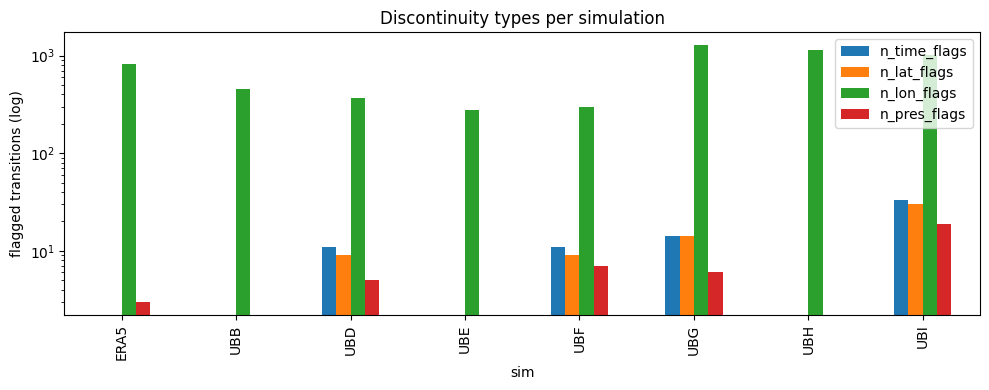

In [7]:
flag_cols = ['n_time_flags', 'n_lat_flags', 'n_lon_flags', 'n_pres_flags']
summary.set_index('sim')[flag_cols].plot(kind='bar', figsize=(10, 4), logy=True)
plt.ylabel('flagged transitions (log)')
plt.title('Discontinuity types per simulation')
plt.tight_layout()
plt.show()

## Inspect one flagged storm visually

Plot lat, lon, pressure along the `point` axis for the most-flagged storm of one simulation, so it's easy to see whether the issue is a single spike, a trajectory split, or interleaved tracks.

Loading data from: /home/vdemeyer/projects/rrg-gachon/vdemeyer/TRACKING/KATJA/OUTPUTS/EETC/EETC_cum_ERA5_Quebec_1000hPa_1979-2023_compound_8hrs_quantile_SSI_diff.pkl with False period filtering


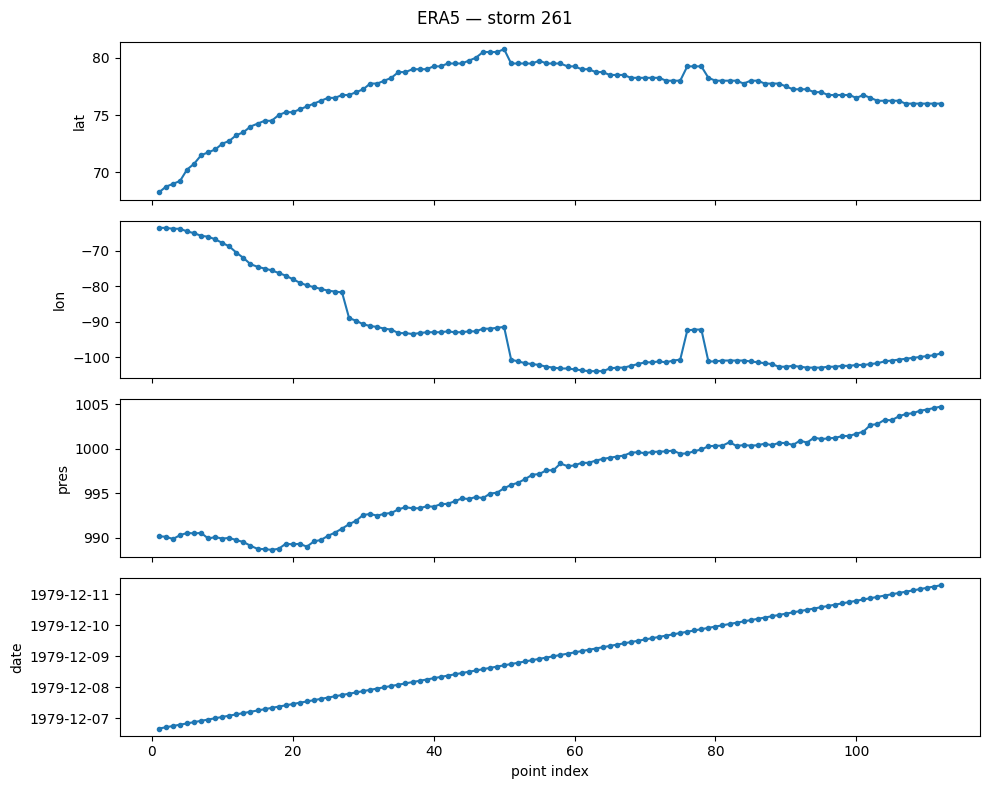

In [8]:
def plot_storm(sim, storm_id):
    df, _ = open_files(sim, period_filtering=False)
    s = df[df['storm'] == storm_id].sort_values('point')

    fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
    axes[0].plot(s['point'], s['lat'], marker='.'); axes[0].set_ylabel('lat')
    axes[1].plot(s['point'], s['lon'], marker='.'); axes[1].set_ylabel('lon')
    axes[2].plot(s['point'], s['pressure'], marker='.'); axes[2].set_ylabel('pres')
    axes[3].plot(s['point'], s['date'], marker='.'); axes[3].set_ylabel('date')
    axes[-1].set_xlabel('point index')
    fig.suptitle(f'{sim} — storm {storm_id}')
    plt.tight_layout()
    plt.show()

if len(top_per_sim) > 0:
    row = top_per_sim.iloc[0]
    plot_storm(row['sim'], int(row['storm']))

## Notes on the Fortran algorithm

The example given (`UBI` year 2067, storm 255) shows several symptoms in one storm:
- the date goes **backwards** between consecutive points (2067090413 → 2067090501 → 2067090502 → **2067090421** → **2067090417**),
- longitudes jump by tens of degrees (-47.89 → -111.88) and also switch convention (247.97 appears mid-track among -40° values),
- pressure jumps by 28 hPa in one step.

This is not a single-point smoothing glitch — it looks like distinct tracks being concatenated under the same storm ID. The most likely culprits in `storm_tracks.f90` are the track-matching step (nearest-candidate selection across time steps) and the storm-ID reuse logic across month boundaries. That's worth inspecting in the Fortran side once we have the full list of affected storms from the CSVs written above.